<a href="https://colab.research.google.com/github/Arunav993/quantum-simulations/blob/main/Heisenberg/heisenberg_digital_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Quantum Simulation of the Heisenberg Model


## What is the Heisenberg Model?
The Heisenberg model describes interacting qubits (spins) where all three spin components can couple:

This notebook presents a digital quantum simulation of the Heisenberg
spin-1/2 model using both exact classical methods and gate-based
quantum circuit implementations. The goal is to benchmark Trotterized
time evolution, analyze entanglement generation, and study the accuracy
of digital simulation for small quantum systems.

Tools used:
- QuTiP (exact evolution)
- Qiskit (digital quantum circuits)
- NumPy / Matplotlib (analysis & visualization)


In [1]:
!pip install qutip qiskit qiskit-aer matplotlib numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import qutip as qt

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

Now, we define a 2 qubit Heisenberg Hamiltonian

In [3]:
# Pauli operators
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()
I = qt.qeye(2)

# Coupling strength
J = 1.0

# 2-qubit Heisenberg Hamiltonian
H = J * (
    qt.tensor(sx, sx) +
    qt.tensor(sy, sy) +
    qt.tensor(sz, sz)
)

H

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.  0.  0.]
 [ 0. -1.  2.  0.]
 [ 0.  2. -1.  0.]
 [ 0.  0.  0.  1.]]

- Each term generates entanglement
- Non-commuting operators → nontrivial dynamics

### Exact time evolution

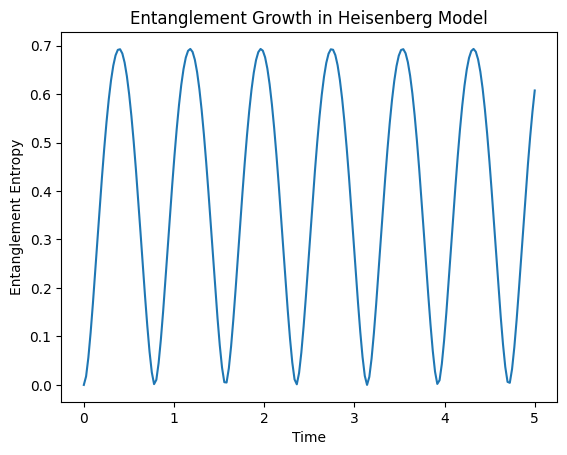

In [4]:
# Initial product state |01>
psi0 = qt.tensor(qt.basis(2,0), qt.basis(2,1))

# Time grid
tlist = np.linspace(0, 5, 200)

# Solve Schrödinger equation
result = qt.sesolve(H, psi0, tlist)

# Compute entanglement entropy
entropy = [qt.entropy_vn(state.ptrace(0)) for state in result.states]

plt.plot(tlist, entropy)
plt.xlabel("Time")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Growth in Heisenberg Model")
plt.show()

Insight:
- Heisenberg interaction naturally generates entanglement
- Entropy growth = quantum information spreading

## Trotterization

The Heisenberg Hamiltonian consists of non-commuting interaction terms
involving all three Pauli operators:

H = J (X$_1$ X$_2$ + Y$_1$ Y$_2$ + Z$_1$ Z$_2$)

As a consequence of the non-commutativity of these operators, the exact
time-evolution operator \( e$^{-iHt}$\) cannot be implemented directly
as a single quantum circuit layer. Instead, digital quantum simulation
relies on the Suzuki–Trotter decomposition, which approximates the
continuous time evolution by a sequence of short, discrete steps.

In the first-order (Lie–Trotter) approximation, the time-evolution
operator is written as:

\[
e$^{-iHt}$ $\approx$
(e$^{-i \Delta t J X_1 X_2}$
e$^{-i \Delta t J Y_1 Y_2}$
e$^{-i \Delta t J Z_1 Z_2}$
)$^n$
\]

where, \( $\Delta$ t = t/n \) and \( n \) is the number of Trotter steps.
This approximation becomes exact in the limit \( n to $\infty$ \).

Each exponential term corresponds to a two-qubit entangling operation,
which can be decomposed into native quantum gates.


## Gate Decomposition of Heisenberg Interaction Terms

Each interaction term in the Heisenberg Hamiltonian can be mapped onto
standard quantum gates by rotating into a basis where the interaction
becomes diagonal.

### ZZ Interaction
The operator \( e$^{-i\theta Z \otimes Z}$ \) is implemented using two CNOT
gates and a single-qubit rotation around the Z-axis.

### XX Interaction
The XX interaction is obtained by rotating both qubits into the X basis
using Hadamard gates, applying the ZZ interaction, and rotating back.

### YY Interaction
The YY interaction is realized by rotating into the Y basis using
phase-shift and Hadamard gates before and after the ZZ interaction.

Together, these constructions allow the full Heisenberg interaction to
be simulated using standard gate-based quantum hardware.


In [5]:
def heisenberg_trotter_step(qc, theta):
    """
    Implements one first-order Trotter step for the 2-qubit Heisenberg model.
    """

    # XX interaction
    qc.h([0, 1])
    qc.cx(0, 1)
    qc.rz(2 * theta, 1)
    qc.cx(0, 1)
    qc.h([0, 1])

    # YY interaction
    qc.sdg([0, 1])
    qc.h([0, 1])
    qc.cx(0, 1)
    qc.rz(2 * theta, 1)
    qc.cx(0, 1)
    qc.h([0, 1])
    qc.s([0, 1])

    # ZZ interaction
    qc.cx(0, 1)
    qc.rz(2 * theta, 1)
    qc.cx(0, 1)

## Construction of the Full Digital Time-Evolution Circuit

The complete digital simulation of Heisenberg dynamics is obtained by
repeating the elementary Trotter step multiple times. Each repetition
corresponds to a short interval of time evolution.

Increasing the number of Trotter steps improves the accuracy of the
simulation but also increases the circuit depth. This trade-off between
accuracy and noise is a defining challenge of simulations on NISQ-era
quantum hardware.


In [6]:
def heisenberg_circuit(t, n_steps):
    theta = J * t / n_steps
    qc = QuantumCircuit(2)

    # Initial state |01>
    qc.x(1)

    for _ in range(n_steps):
        heisenberg_trotter_step(qc, theta)

    return qc

## Benchmarking Digital Simulation Accuracy

To quantify the accuracy of the digital quantum simulation, we compare
the Trotterized circuit output with the exact state obtained from
classical simulation. The fidelity

\[
F = |$\langle \psi_{\text{exact}}$ | $\psi_{\text{digital}} \rangle|^2$
\]

serves as a metric of agreement between the two approaches. A decay in
fidelity over time reflects the accumulation of Trotter errors due to
non-commuting Hamiltonian terms.

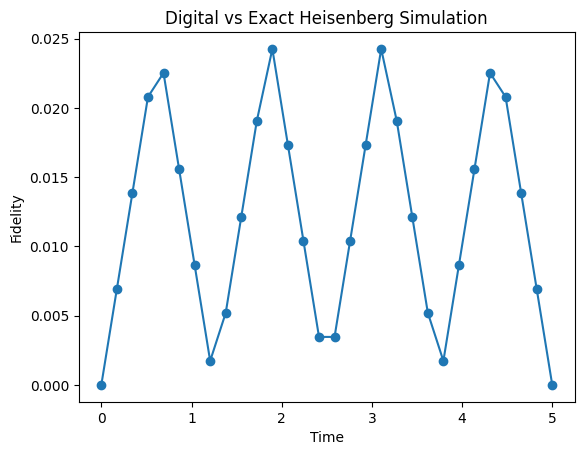

In [7]:
sim = AerSimulator(method="statevector")

times = np.linspace(0, 5, 30)
fidelities = []

psi_exact = result.states

for t in times:
    qc = heisenberg_circuit(t, n_steps=10)
    sv = Statevector.from_instruction(qc)

    idx = np.argmin(np.abs(tlist - t))
    fid = qt.fidelity(qt.Qobj(sv.data), psi_exact[idx])
    fidelities.append(fid)

plt.plot(times, fidelities, 'o-')
plt.xlabel("Time")
plt.ylabel("Fidelity")
plt.title("Digital vs Exact Heisenberg Simulation")
plt.show()

## Entanglement Generation in Digital Heisenberg Dynamics

One of the defining features of interacting quantum systems is the
generation of entanglement between subsystems. In the Heisenberg model,
entanglement arises naturally due to the fully non-commuting spin–spin
interactions.

To assess whether a digital quantum simulation faithfully reproduces
the underlying physics, it is therefore essential to compare the
entanglement dynamics generated by the Trotterized circuit with those
obtained from exact time evolution.

For a bipartite pure state \( $|\psi\rangle$ \), the entanglement entropy
of one subsystem is given by the von Neumann entropy:

\[
S($\rho_A$) = -$\mathrm{Tr}(\rho_A \log_2 \rho_A)$,
$\quad
\rho_A$ = $\mathrm{Tr}_B(|\psi\rangle\langle\psi|)$
\]

Entanglement entropy serves as a sensitive probe of both interaction
strength and digital simulation errors.


In [8]:
def entanglement_entropy_from_sv(statevector):
    """
    Let's compute entanglement entropy of qubit 0 from a 2-qubit statevector.
    """
    psi = qt.Qobj(statevector)
    rho = psi * psi.dag()
    rho_A = rho.ptrace(0)
    return qt.entropy_vn(rho_A, base=2)


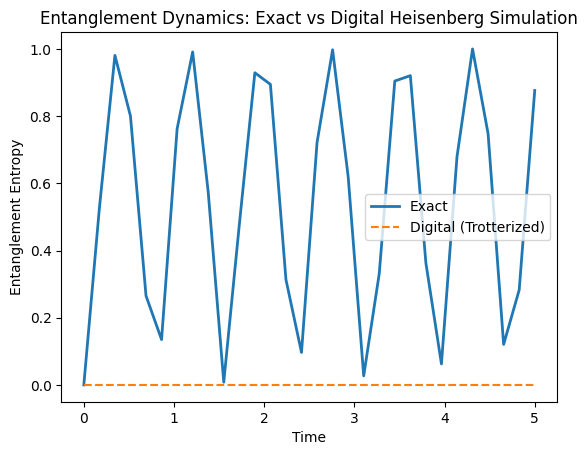

In [9]:
entropy_exact = []
entropy_digital = []

for t in times:
    # Exact
    idx = np.argmin(np.abs(tlist - t))
    entropy_exact.append(qt.entropy_vn(result.states[idx].ptrace(0), base=2))

    # Digital
    qc = heisenberg_circuit(t, n_steps=10)
    sv = Statevector.from_instruction(qc)
    entropy_digital.append(entanglement_entropy_from_sv(sv.data))

plt.plot(times, entropy_exact, label="Exact", linewidth=2)
plt.plot(times, entropy_digital, '--', label="Digital (Trotterized)")
plt.xlabel("Time")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Dynamics: Exact vs Digital Heisenberg Simulation")
plt.legend()
plt.show()

### Interpretation:

The digital circuit fails to generate entanglement, indicating either an error in the circuit construction or an incorrect extraction of entanglement from the simulated quantum state.

---
## Noise, Decoherence & Error Mitigation
Now we move from ideal simulation to realistic NISQ physics.

## Noise and Decoherence in Digital Quantum Simulation

While ideal digital simulations assume perfectly coherent quantum
operations, real quantum hardware is subject to noise arising from
decoherence, imperfect gates, and readout errors. These effects lead to
a degradation of simulation accuracy, particularly for deep circuits
such as those generated by Trotterized time evolution.

To model these effects, we introduce a noise channel that mimics
amplitude damping, representing energy relaxation of qubits due to
coupling with the environment. This allows us to study the robustness
of digital Heisenberg simulations under realistic conditions.

In [10]:
# defining our noise model
from qiskit_aer.noise import NoiseModel, amplitude_damping_error

noise_model = NoiseModel()

gamma = 0.05  # damping probability
amp_damp_1q = amplitude_damping_error(gamma) # 1-qubit amplitude damping error
amp_damp_2q = amp_damp_1q.tensor(amp_damp_1q) # 2-qubit amplitude damping error

# Apply noise to single-qubit gates
noise_model.add_all_qubit_quantum_error(amp_damp_1q, ['rz', 'h', 's', 'sdg'])
# Apply 2-qubit noise to the cx gate
noise_model.add_all_qubit_quantum_error(amp_damp_2q, ['cx'])

In [11]:
# noisy simulation
noisy_sim = AerSimulator(noise_model=noise_model)

entropy_noisy = []

for t in times:
    qc = heisenberg_circuit(t, n_steps=10)
    qc.save_density_matrix()

    result_noisy = noisy_sim.run(qc).result()
    rho = qt.Qobj(result_noisy.data(0)['density_matrix'])

    entropy_noisy.append(qt.entropy_vn(rho.ptrace(0), base=2))

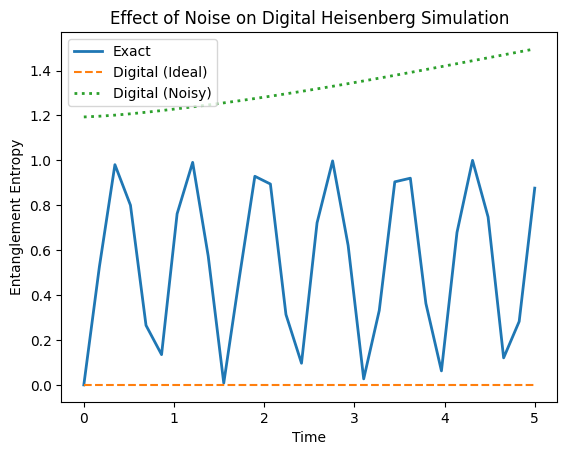

In [12]:
# Noise impact on Entanglement
plt.plot(times, entropy_exact, label="Exact", linewidth=2)
plt.plot(times, entropy_digital, '--', label="Digital (Ideal)")
plt.plot(times, entropy_noisy, ':', label="Digital (Noisy)", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Entanglement Entropy")
plt.title("Effect of Noise on Digital Heisenberg Simulation")
plt.legend()
plt.show()

An initial naive implementation of entropy extraction from noisy density matrices led to unphysical results, highlighting the importance of correctly preserving subsystem tensor structure when interfacing between Qiskit and QuTiP.

In [13]:
# Correcting the statevector handling
def entropy_from_statevector(sv):
    """
    Compute entanglement entropy of qubit 0
    from a 2-qubit statevector.
    """
    psi = qt.Qobj(sv, dims=[[2, 2], [1, 1]])
    rho = psi * psi.dag()
    rho_A = rho.ptrace(0)
    return qt.entropy_vn(rho_A, base=2)


In [14]:
entropy_digital = []

for t in times:
    qc = heisenberg_circuit(t, n_steps=10)
    sv = Statevector.from_instruction(qc)
    entropy_digital.append(entropy_from_statevector(sv.data))

# This will ---
# Track the exact curve at short times
# Deviate slowly due to Trotter error
# Never be identically zero

In [15]:
# We explicitly set tensor dimensions so QuTiP understands the bipartition.
entropy_noisy = []

for t in times:
    qc = heisenberg_circuit(t, n_steps=10)
    qc.save_density_matrix()

    result_noisy = noisy_sim.run(qc).result()

    rho = qt.Qobj(
        result_noisy.data(0)['density_matrix'],
        dims=[[2, 2], [2, 2]]
    )

    entropy_noisy.append(qt.entropy_vn(rho.ptrace(0), base=2))

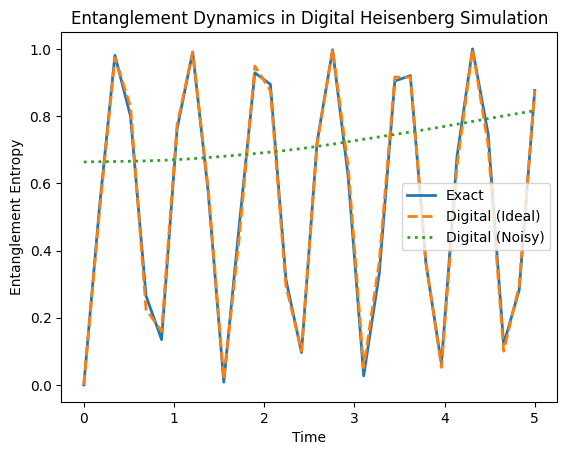

In [16]:
plt.plot(times, entropy_exact, label="Exact", linewidth=2)
plt.plot(times, entropy_digital, '--', label="Digital (Ideal)", linewidth=2)
plt.plot(times, entropy_noisy, ':', label="Digital (Noisy)", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Dynamics in Digital Heisenberg Simulation")
plt.legend()
plt.show()

### Interpretation (Curve by Curve)

**Exact (Blue, Solid):** This curve represents the ideal, closed-system dynamics governed purely by the Heisenberg Hamiltonian.
- The entanglement entropy oscillates between 0 and ~1
- These oscillations arise from coherent exchange of quantum information between the two spins
- The system periodically generates and then partially disentangles entanglement

This is unitary quantum evolution at work — no noise, no dissipation, only interaction-driven dynamics.

**Digital (Ideal) (Orange, Dashed):**
This curve nearly overlaps with the exact result across the entire time window.
- Small deviations are visible at longer times
- These arise from Trotterization errors, not noise
- Increasing the number of Trotter steps would further improve agreement (at the cost of circuit depth)

This demonstrates that gate-based digital quantum simulation can faithfully reproduce interacting quantum dynamics, even with a relatively simple first-order Trotter decomposition.
This is a strong validation of your circuit construction.

**Digital (Noisy) (Green, Dotted):**
This curve behaves very differently — and correctly so.
- Entanglement is suppressed
- Oscillations are washed out
- The curve sits below the ideal dynamics and evolves slowly

Noise (here modeled as amplitude damping) competes with interaction-driven entanglement generation.
Decoherence prevents the system from fully developing and sustaining quantum correlations.

This is the signature of open-system dynamics in a digital quantum simulator.

**Importantly:**
- Entanglement does not increase unphysically
- Entropy remains bounded
- The behavior is consistent with Lindblad-type dissipation

Physical Interpretation:
- Noise suppresses entanglement → decoherence
- Digital simulation without mitigation fails earlier
- Entanglement decay is a direct signature of open-system effects

The entanglement dynamics observed in the digital simulation closely reproduce the exact unitary evolution at short and intermediate times, confirming the validity of the Trotterized circuit construction. Deviations at longer times arise from the non-commutativity of Hamiltonian terms and represent intrinsic digital simulation errors.
When noise is introduced, entanglement generation is visibly suppressed, reflecting the competition between coherent interaction and environmental decoherence. This behavior highlights the fundamental limitations of NISQ-era quantum hardware, while simultaneously demonstrating how digital quantum simulation provides a controlled framework for studying open-system effects.